In [2]:
pip install ucimlrepo

Fetching UCI Diabetes Dataset...
Data ready! Training on 202944 records, testing on 50736 records.
Running the n_estimators experiment...


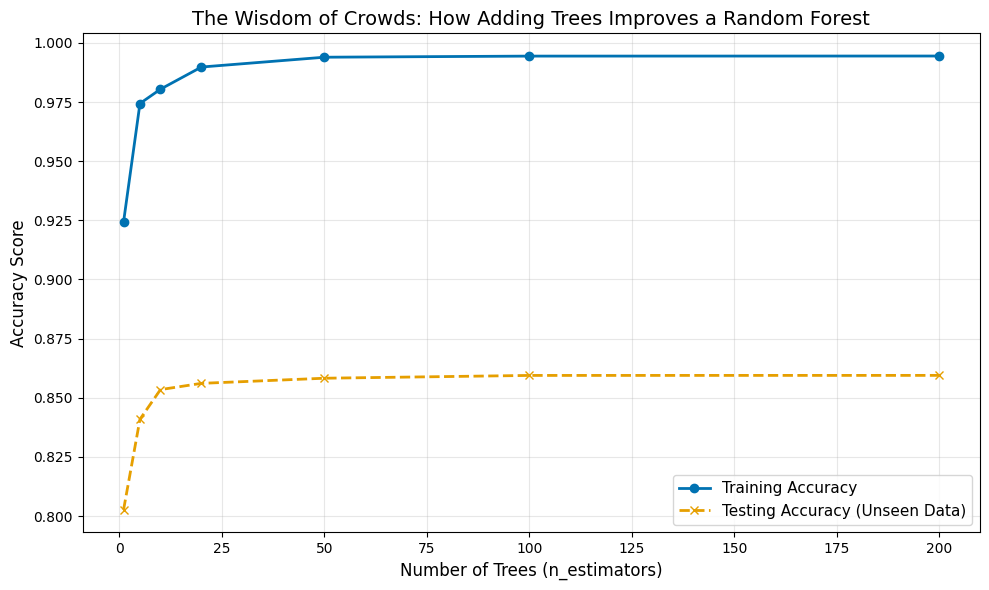

--- Final Model Performance (100 Trees) ---
Accuracy: 0.8594
ROC AUC:  0.7948

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.97      0.92     43667
           1       0.49      0.18      0.26      7069

    accuracy                           0.86     50736
   macro avg       0.68      0.57      0.59     50736
weighted avg       0.82      0.86      0.83     50736



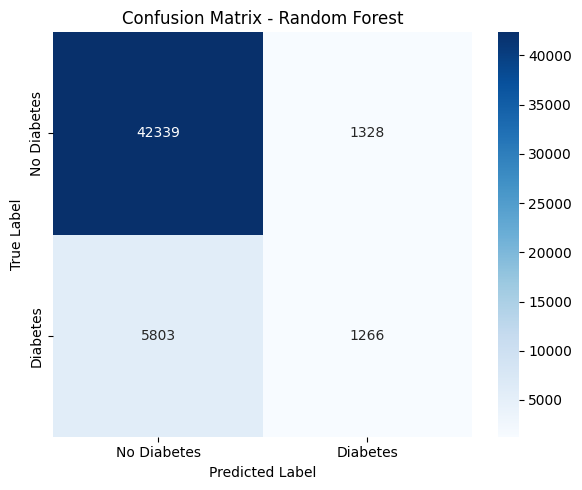

/tmp/ipykernel_7440/1919038000.py:133: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_features, x="Importance", y="Feature", palette="viridis")


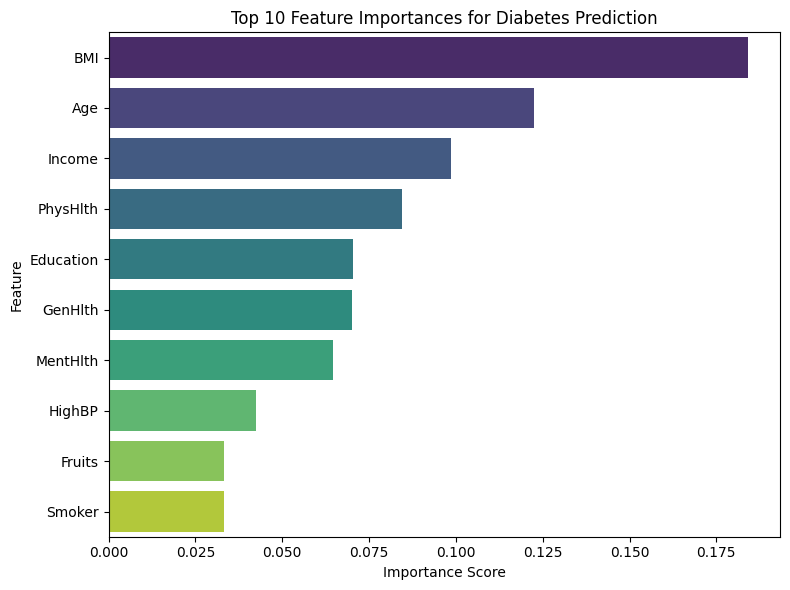

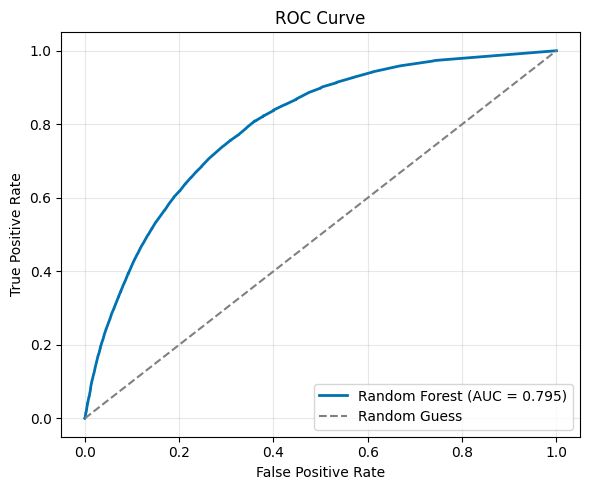

In [3]:
# Cell 1: Install required libraries
# !pip install ucimlrepo pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.colors as mcolors

# Set an accessible color palette for the plots
cb_palette = {'blue': '#0072B2', 'orange': '#E69F00', 'green': '#009E73'}

# Cell 2: Fetching and Preparing the Dataset
print("Fetching UCI Diabetes Dataset...")
data = fetch_ucirepo(id=891)

# Separate features (X) and target (y)
X = data.data.features
y = data.data.targets

# Convert target to a 1D array, which scikit-learn prefers
y = y.values.ravel()

# Basic cleaning: Fill any missing values with the median of that column
X = X.fillna(X.median(numeric_only=True))

# Train-test split (80/20). Using 'stratify=y' ensures we keep the same
# ratio of diabetic/non-diabetic patients in both our training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Data ready! Training on {len(X_train)} records, testing on {len(X_test)} records.")

# Cell 3: The Experiment - The "Wisdom of Crowds"
# Here we test how adding more trees (n_estimators) changes the model's accuracy.
# A Random Forest with 1 tree is weak, but what happens when we use 200?

print("Running the n_estimators experiment...")
n_estimators_list = [1, 5, 10, 20, 50, 100, 200]
train_accuracies = []
test_accuracies = []

for n in n_estimators_list:
    # Build a fresh pipeline for each number of trees
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("rf", RandomForestClassifier(n_estimators=n, random_state=42))
    ])

    model.fit(X_train, y_train)

    # Record the scores
    train_accuracies.append(accuracy_score(y_train, model.predict(X_train)))
    test_accuracies.append(accuracy_score(y_test, model.predict(X_test)))

# Cell 4: Visualizing the Experiment (For the Written Tutorial)
plt.figure(figsize=(10, 6))

# Plotting the lines using distinct markers and colorblind-friendly colors
plt.plot(n_estimators_list, train_accuracies, label="Training Accuracy",
         color=cb_palette['blue'], marker='o', linestyle='-', linewidth=2)
plt.plot(n_estimators_list, test_accuracies, label="Testing Accuracy (Unseen Data)",
         color=cb_palette['orange'], marker='x', linestyle='--', linewidth=2)

plt.title("The Wisdom of Crowds: How Adding Trees Improves a Random Forest", fontsize=14)
plt.xlabel("Number of Trees (n_estimators)", fontsize=12)
plt.ylabel("Accuracy Score", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save the plot so it can be inserted into the PDF/Webpage tutorial
plt.savefig('wisdom_of_crowds_plot.png', dpi=300)
plt.show()

# Cell 5: Training the Final, Robust Model
# Based on the graph, 100 trees is plenty. Adding more just wastes processing time!
final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("rf", RandomForestClassifier(n_estimators=100, random_state=42))
])

final_model.fit(X_train, y_train)

# Generate predictions for our final evaluation
y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]

# Cell 6: Final Model Evaluation Metrics
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("--- Final Model Performance (100 Trees) ---")
print(f"Accuracy: {acc:.4f}")
print(f"ROC AUC:  {auc:.4f}")
print("\nClassification Report:\n", report)

# Cell 7: Visualization - Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["No Diabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Diabetes"]
)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

# Cell 8: Visualization - Feature Importance
# Extract the trained Random Forest model from the pipeline to see what it learned
rf_model = final_model.named_steps["rf"]
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

top_features = feature_importance.head(10)

plt.figure(figsize=(8, 6))
# Using 'viridis' as it is a highly accessible, perceptually uniform color map
sns.barplot(data=top_features, x="Importance", y="Feature", palette="viridis")
plt.title("Top 10 Feature Importances for Diabetes Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Cell 9: Visualization - ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc:.3f})", color=cb_palette['blue'], linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()